# Loading GRIB files from S3 bucket

This notebook provides details on the available GRIB files for the [hplp experiment](https://apps.ecmwf.int/mars-catalogue/?class=rd&expver=hplp), i.e. the parameters, levels, and steps as well as instructions on how to use the `load_grib_files` function for loading GRIB files from the S3 bucket at [https://object-store.os-api.cci1.ecmwf.int/esiwacebucket](https://object-store.os-api.cci1.ecmwf.int/esiwacebucket).

## Available Pressure Level Parameters
The following parameters are available pressure level fields:
```python
[129, 130, 133, 135, 138, 155, 131, 132, 157]
```
They are stored at the following levels:
```python
[1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100, 150, 200, 250, 300, 400, 500, 700, 850, 925, 1000]
```


## Available Model Level Parameters
The following parameters are available model level fields:
```python
[75, 76, 129, 130, 131, 132, 133, 135, 138, 152, 155, 203, 246, 247, 248]
```
They are stored at the following levels:
```python
[list(range(1, 138)) # Levels 1 to 137
```
### Please note that, currently, only data for model level param 75 is available.

## Available Steps 

The following steps are available for both pressure and model levels: 

```python 
 [0, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 132, 144, 156, 168, 180, 192, 204, 216, 228, 240]
 ```


## Using the `load_grib_files` Function

To load GRIB files, you can use the following function:

```python
load_grib_files(leveltype=None, params=None, levels=None, steps=None)
```

### Parameters:
-   **leveltype**: Specify either `"pl"` for pressure level files or `"ml"` for model level files.
-   **params**: A list of model parameters you wish to load. The codes must be valid according to the specified `leveltype`.
-   **levels**: A list of pressure or model levels for which data is requested.
-   **steps**: A list of forecast steps for which data is requested.

If **params**, **levels** or **steps** are not specified, all available data will be loaded used based on the **leveltype**.

In [35]:
import earthkit
import pandas as pd

default_steps = [0, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 132, 144, 156, 168, 180, 192, 204, 216, 228, 240]
default_pl_levels = [1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100, 150, 200, 250, 300, 400, 500, 700, 850, 925, 1000]
default_pl_params = [129, 130, 133, 135, 138, 155, 131, 132, 157]
default_ml_levels = list(range(1, 138))
default_ml_params = [75, 76, 129, 130, 131, 132, 133, 135, 138, 152, 155, 203, 246, 247, 248]
available_ml_param = [75] # Currently available model level params in the S3 bucket


# URL of S3 bucket
BASE_URL = "https://object-store.os-api.cci1.ecmwf.int/esiwacebucket"


In [36]:
def load_grib_files(leveltype=None, params=None, levels=None, steps=None):
    if leveltype not in ["pl", "ml"]:
        print(f"Error: Invalid leveltype '{leveltype}'")
        return
    
    valid_params = default_pl_params if leveltype == "pl" else default_ml_params
    valid_levels = default_pl_levels if leveltype == "pl" else default_ml_levels
    valid_steps = default_steps

    params = params or valid_params
    levels = levels or valid_levels
    steps = steps or (default_steps if 133 in params and leveltype == "pl" else [None])

    invalid_params = [param for param in params if param not in valid_params]
    invalid_levels = [level for level in levels if level not in valid_levels]
    invalid_steps = [step for step in steps if step not in valid_steps and step is not None]

    if invalid_params:
        print(f"Error: Invalid params {invalid_params}")
        return
    if invalid_levels:
        print(f"Error: Invalid levels {invalid_levels}")
        return
    if invalid_steps:
        print(f"Error: Invalid steps {invalid_steps}")
        return

    urls = []
    for param in params:
        if leveltype == "ml" and param not in available_ml_param:
            print(f"Error: Data for param {param} is not available.")
            continue
        
        for level in levels:
            if param == 133 and leveltype == "pl":
                urls.extend([f"{BASE_URL}/hplp_pl_param_{param}_level_{level}_step_{step}.grib" for step in steps])
            elif leveltype == "ml":
                urls.extend([f"{BASE_URL}/hplp_ml_param_{param}_level_{level}_step_{step}.grib" for step in steps])
            else:
                if steps != [None]:
                    print(f"Warning: Steps specified for param {param}, only applicable to param 133. Ignoring steps.")
                urls.append(f"{BASE_URL}/hplp_pl_param_{param}_level_{level}.grib")

    if not urls:
        print("No valid files to download.")
        return

    try:
        combined_data = earthkit.data.from_source("url", urls)
        print(f"Downloaded and combined {len(urls)} files.")
        return combined_data
    except Exception as e:
        print(f"Failed to download and combine files: {e}")
        return None


## Example Usage

To download GRIB files for pressure level parameters, you could use the following which would download the GRIB files for parameter 133 at pressure level 1000 for the specified step 12. 

In [33]:
data1 = load_grib_files(leveltype="pl", params=[133], levels=[1,2], steps=[12])


<multiple>:   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Downloaded and combined 2 files.


In [34]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(data1.ls(extra_keys =["paramId"]))

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType,paramId
0,ecmf,q,isobaricInhPa,1,20200721,0,12,fc,0,reduced_gg,133
1,ecmf,q,isobaricInhPa,2,20200721,0,12,fc,0,reduced_gg,133


For all pressure level parameters except 133, there is only one file for all available steps therefore all of them will be loaded regardless of the specified steps. For param 133 they are split for size reasons.

In [31]:
data2 = load_grib_files(leveltype="pl", params=[133, 130], levels=[1], steps=[12])


<multiple>:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Downloaded and combined 2 files.


In [28]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(data2.ls(extra_keys =["paramId"]))

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType,paramId
0,ecmf,q,isobaricInhPa,1,20200721,0,12,fc,0,reduced_gg,133
1,ecmf,t,isobaricInhPa,1,20200721,0,0,fc,0,sh,130
2,ecmf,t,isobaricInhPa,1,20200721,0,12,fc,0,sh,130
3,ecmf,t,isobaricInhPa,1,20200721,0,24,fc,0,sh,130
4,ecmf,t,isobaricInhPa,1,20200721,0,36,fc,0,sh,130
5,ecmf,t,isobaricInhPa,1,20200721,0,48,fc,0,sh,130
6,ecmf,t,isobaricInhPa,1,20200721,0,60,fc,0,sh,130
7,ecmf,t,isobaricInhPa,1,20200721,0,72,fc,0,sh,130
8,ecmf,t,isobaricInhPa,1,20200721,0,84,fc,0,sh,130
9,ecmf,t,isobaricInhPa,1,20200721,0,96,fc,0,sh,130


The data can be plotted as shown below. Please note that only the reduced Gaussian grid fields can be plotted, i.e. only param 133 (specific humidity q).

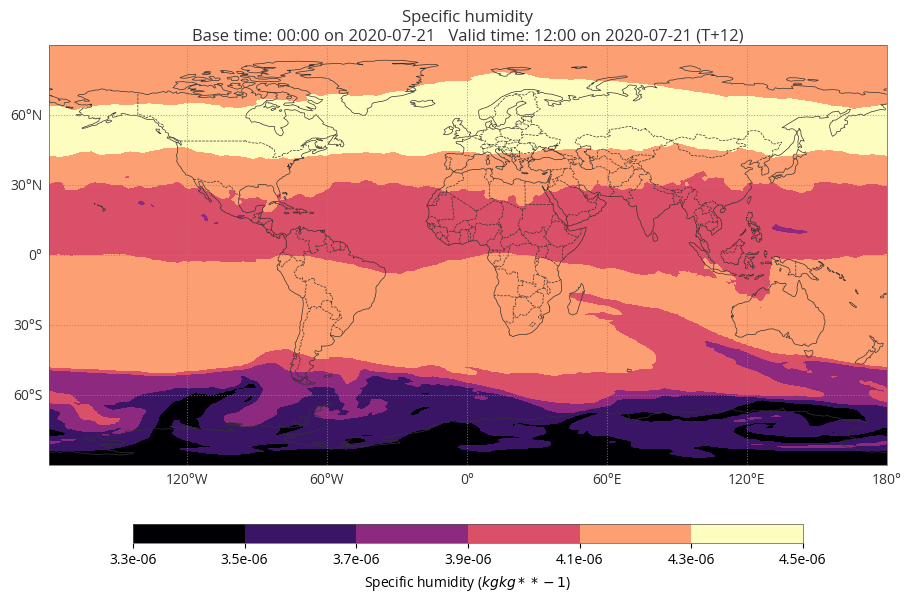

In [32]:
earthkit.maps.quickplot(data2.sel(shortName="q"))